<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2024</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **DateoFdeath**: дата смерти

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1jz0wUqHW41b-Xhk1yCn1__gh_rgVSOJJ # train dataset
!gdown 1RCb9VuAw_6Ic7pnut6XnnL8soCRDnk2W # test dataset

"gdown" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"gdown" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [3]:
data = pd.read_csv('../DataBases/game_of_thrones_train.csv', index_col='S.No')
data.head(3)

,name,title,male,culture,dateOfBirth,DateoFdeath,mother,father,heir,house,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,NaN,House Frey,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,NaN,House Swyft,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1


In [4]:
data.nunique()

name                1557
title                195
male                   2
culture               51
dateOfBirth          105
DateoFdeath           61
mother                16
father                19
heir                  20
house                315
spouse               186
book1                  2
book2                  2
book3                  2
book4                  2
book5                  2
isAliveMother          2
isAliveFather          2
isAliveHeir            2
isAliveSpouse          2
isMarried              2
isNoble                2
age                   72
numDeadRelations      14
popularity           117
isAlive                2
dtype: int64

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   DateoFdeath       307 non-null    float64
 6   mother            18 non-null     object 
 7   father            22 non-null     object 
 8   heir              21 non-null     object 
 9   house             1176 non-null   object 
 10  spouse            200 non-null    object 
 11  book1             1557 non-null   int64  
 12  book2             1557 non-null   int64  
 13  book3             1557 non-null   int64  
 14  book4             1557 non-null   int64  
 15  book5             1557 non-null   int64  
 16  isAliveMother     18 non-null     float64
 17  

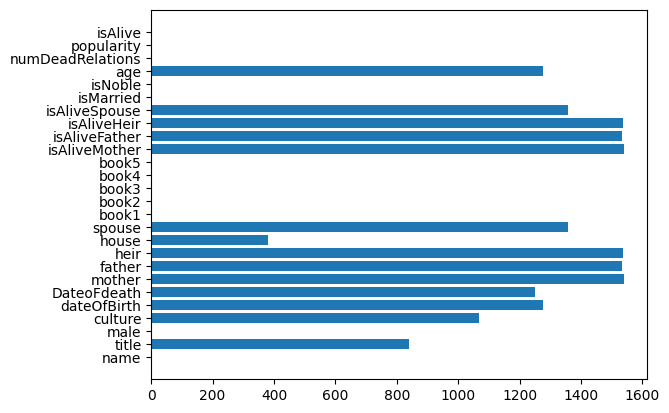

In [6]:
data_nan = data.isna().sum()
plt.barh(data_nan.index, data_nan.values);

In [7]:
for col in data.columns:
    print(f'Пропущенных значений в {col}: {data[col].isna().sum() / len(data[col]) * 100}%')

Пропущенных значений в name: 0.0%
Пропущенных значений в title: 53.94990366088632%
Пропущенных значений в male: 0.0%
Пропущенных значений в culture: 68.65767501605652%
Пропущенных значений в dateOfBirth: 82.08092485549133%
Пропущенных значений в DateoFdeath: 80.28259473346179%
Пропущенных значений в mother: 98.84393063583815%
Пропущенных значений в father: 98.58702633269107%
Пропущенных значений в heir: 98.65125240847784%
Пропущенных значений в house: 24.470134874759154%
Пропущенных значений в spouse: 87.15478484264611%
Пропущенных значений в book1: 0.0%
Пропущенных значений в book2: 0.0%
Пропущенных значений в book3: 0.0%
Пропущенных значений в book4: 0.0%
Пропущенных значений в book5: 0.0%
Пропущенных значений в isAliveMother: 98.84393063583815%
Пропущенных значений в isAliveFather: 98.58702633269107%
Пропущенных значений в isAliveHeir: 98.65125240847784%
Пропущенных значений в isAliveSpouse: 87.15478484264611%
Пропущенных значений в isMarried: 0.0%
Пропущенных значений в isNoble: 0.

#### Удаление колонок, где слишком много Nan

In [8]:
data_cols = data.columns[data_nan > len(data) // 2]

In [9]:
data.drop(data_cols, axis=1, inplace=True)

In [10]:
data.shape  # остлось 13 признаков

(1557, 13)

#### Обработка остальных колонок с Nan

In [11]:
data.isna().sum()  # осталась всего одна колонка с Nan

name                  0
male                  0
house               381
book1                 0
book2                 0
book3                 0
book4                 0
book5                 0
isMarried             0
isNoble               0
numDeadRelations      0
popularity            0
isAlive               0
dtype: int64

In [20]:
the_most_frequent_houses = data['house'].value_counts().index[:2].to_list()
the_most_frequent_houses  # самые популярные дома

['House Frey', "Night's Watch"]

In [21]:
data['house'].value_counts()

house
House Frey          89
Night's Watch       88
House Stark         56
House Targaryen     40
House Lannister     36
                    ..
House Celtigar       1
House of Ghazeen     1
House Byrch          1
House Hawick         1
House Moore          1
Name: count, Length: 315, dtype: int64

In [38]:
data['house'] = [np.random.choice(the_most_frequent_houses) if pd.isna(i) else i for i in data.house]  # заменяем nan на значения моды
data.isna().sum()

name                0
male                0
house               0
book1               0
book2               0
book3               0
book4               0
book5               0
isMarried           0
isNoble             0
numDeadRelations    0
popularity          0
isAlive             0
dtype: int64

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


#### Работа с признаком house

In [59]:
data.house.value_counts().loc[data.house.value_counts() > 5].head()

house
Night's Watch      291
House Frey         267
House Stark         56
House Targaryen     40
House Lannister     36
Name: count, dtype: int64

In [63]:
small_house_group = data.house.value_counts().loc[data.house.value_counts() < 5].index.to_list()
small_house_group[:5]

['House Harlaw',
 'House Hunter',
 'House Crane',
 'House Mormont',
 'House Goodbrook']

In [72]:
data.house.replace(small_house_group, 'small_house_group', inplace=True)

In [77]:
average_house_group = data.house.value_counts().loc[data.house.value_counts() <= 15].index.to_list()
average_house_group[:5]

['Faith of the Seven',
 'House Hightower',
 'House Botley',
 'House Arryn',
 'House Martell']

In [78]:
data.house.replace(average_house_group, 'average_house_group', inplace=True)

In [80]:
almost_biggest_house_group = data.house.value_counts().loc[data.house.value_counts() <= 100].index.to_list()
average_house_group[:5]

['Faith of the Seven',
 'House Hightower',
 'House Botley',
 'House Arryn',
 'House Martell']

In [85]:
data.house.replace(almost_biggest_house_group, 'almost_biggest_house_group', inplace=True)

In [86]:
data.house.value_counts()

house
small_house_group             455
average_house_group           329
Night's Watch                 291
House Frey                    267
almost_biggest_house_group    215
Name: count, dtype: int64

<BarContainer object of 5 artists>

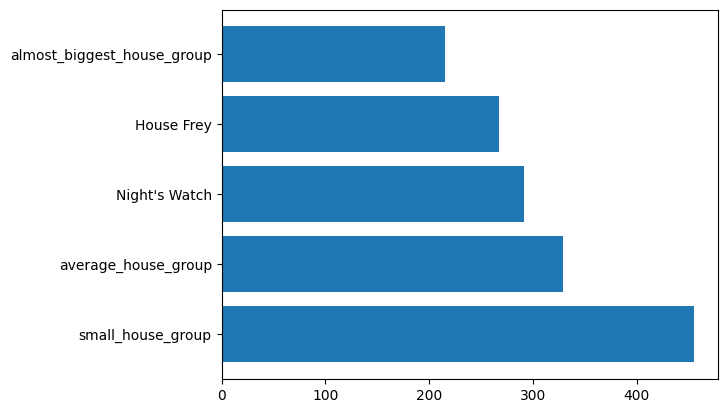

In [87]:
plt.barh(data.house.value_counts().index, data.house.value_counts().values)

In [89]:
for col in data:
    print(f'Количество уникальных значений в {col}: {data[col].nunique()}')

Количество уникальных значений в name: 1557
Количество уникальных значений в male: 2
Количество уникальных значений в house: 5
Количество уникальных значений в book1: 2
Количество уникальных значений в book2: 2
Количество уникальных значений в book3: 2
Количество уникальных значений в book4: 2
Количество уникальных значений в book5: 2
Количество уникальных значений в isMarried: 2
Количество уникальных значений в isNoble: 2
Количество уникальных значений в numDeadRelations: 14
Количество уникальных значений в popularity: 117
Количество уникальных значений в isAlive: 2


#### Работа с признаком popularity

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   male              1557 non-null   int64  
 2   house             1557 non-null   object 
 3   book1             1557 non-null   int64  
 4   book2             1557 non-null   int64  
 5   book3             1557 non-null   int64  
 6   book4             1557 non-null   int64  
 7   book5             1557 non-null   int64  
 8   isMarried         1557 non-null   int64  
 9   isNoble           1557 non-null   int64  
 10  numDeadRelations  1557 non-null   int64  
 11  popularity        1557 non-null   float64
 12  isAlive           1557 non-null   int64  
dtypes: float64(1), int64(10), object(2)
memory usage: 170.3+ KB


In [92]:
is_popular = [0 if i < 0.5 else 1 for i in data.popularity]
data['is_popular'] = is_popular

#### boolDeadRelations

In [96]:
boolDeadRelations = [1 if i > 0 else 0 for i in data['numDeadRelations']]
data['boolDeadRelations'] = boolDeadRelations
data.drop('numDeadRelations', axis=1, inplace=True)

In [97]:
data.head()

,name,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,is_popular,boolDeadRelations
S.No,,,,,,,,,,,,,,
1,Viserys II Targaryen,1,Night's Watch,0,0,0,0,0,0,0,0.605351,0,1,1
2,Walder Frey,1,House Frey,1,1,1,1,1,1,1,0.896321,1,1,1
3,Addison Hill,1,average_house_group,0,0,0,1,0,0,1,0.267559,1,0,0
4,Aemma Arryn,0,average_house_group,0,0,0,0,0,1,1,0.183946,0,0,0
5,Sylva Santagar,0,small_house_group,0,0,0,1,0,1,1,0.043478,1,0,0


In [ ]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [98]:
data.drop(columns=['name'], inplace = True)
data

,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,is_popular,boolDeadRelations
S.No,,,,,,,,,,,,,
1,1,Night's Watch,0,0,0,0,0,0,0,0.605351,0,1,1
2,1,House Frey,1,1,1,1,1,1,1,0.896321,1,1,1
3,1,average_house_group,0,0,0,1,0,0,1,0.267559,1,0,0
4,0,average_house_group,0,0,0,0,0,1,1,0.183946,0,0,0
5,0,small_house_group,0,0,0,1,0,1,1,0.043478,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,House Frey,1,0,1,1,0,0,1,0.160535,1,0,0
1554,0,Night's Watch,1,1,0,0,0,0,0,0.040134,0,0,0
1555,1,average_house_group,0,1,1,1,1,0,0,0.076923,0,0,0


**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

In [104]:
data.isAlive.dtype  # количественная

dtype('int64')

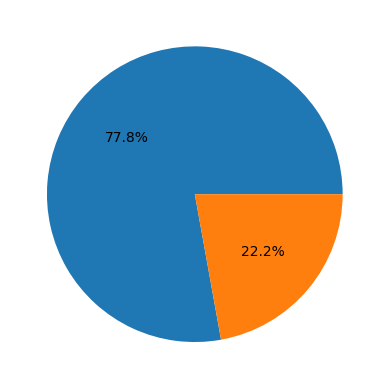

In [103]:
plt.pie(data.isAlive.value_counts(), autopct='%1.1f%%');

In [107]:
data.drop('house', axis=1, inplace=True)
data

,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity,isAlive,is_popular,boolDeadRelations
S.No,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0.605351,0,1,1
2,1,1,1,1,1,1,1,1,0.896321,1,1,1
3,1,0,0,0,1,0,0,1,0.267559,1,0,0
4,0,0,0,0,0,0,1,1,0.183946,0,0,0
5,0,0,0,0,1,0,1,1,0.043478,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,0.160535,1,0,0
1554,0,1,1,0,0,0,0,0,0.040134,0,0,0
1555,1,0,1,1,1,1,0,0,0.076923,0,0,0


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [ ]:
# ...

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [ ]:
# ...

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
X = # ...
y = # ...

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = # ...

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [ ]:
from ... import AdaBoostClassifier, RandomForestClassifier
from ... import GaussianProcessClassifier
from ... import GaussianNB
from ... import KNeighborsClassifier
from ... import SVC
from ... import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели


# Шаг 2. обучение модели


# Шаг 3. Предсказание на тестовых данных


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [ ]:
# Шаг 3. Предсказание на тестовых данных


# Шаг 4. Оценка предсказания по метрике accuracy

print("Accuracy : %.4f" % accuracy)

Выберите лучшую модель.